In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, regexp_extract
import matplotlib.pyplot as plt
import pandas as pd
import os

In [2]:
spark = SparkSession.builder \
    .appName("Momondo Analysis") \
    .config("spark.master", "local[*]") \
    .getOrCreate()

In [8]:
filepath_momondo = "../Kafka_Spark/CSVs/momondo_data.csv"
momondo_df = spark.read.option("header", True).option("inferSchema", True).csv(filepath_momondo)

ziel_airports = ['BER', 'CDG', 'IST', 'LHR']

momondo_df = momondo_df.withColumnRenamed("Stadt", "Zielflughafen")
momondo_df = momondo_df.withColumn("Zielflughafen", 
    regexp_extract(col("Zielflughafen"), "\\((.*?)\\)", 1))

In [4]:
momondo_filtered = momondo_df.filter(col("Abflug_Flughafen").isin(ziel_airports))

# Fehlende Werte entfernen
momondo_filtered = momondo_filtered.dropna()

In [5]:
momondo_fco = momondo_filtered.filter(col("Zielflughafen") == "FCO")
df_avg = momondo_fco.groupBy("Abflug_Flughafen").agg(avg("Preis").alias("Durchschnittspreis"))

# Ausgabe ins Terminal
df_avg.show()

+----------------+------------------+
|Abflug_Flughafen|Durchschnittspreis|
+----------------+------------------+
|             CDG| 190.9090909090909|
|             LHR|          233.3125|
|             BER|191.22222222222223|
+----------------+------------------+



In [6]:
output_path = "mean_prices_to_FCO/momondo_durchschnittspreise_fco.csv"
df_avg.coalesce(1).write.mode("overwrite").option("header", True).csv(output_path)

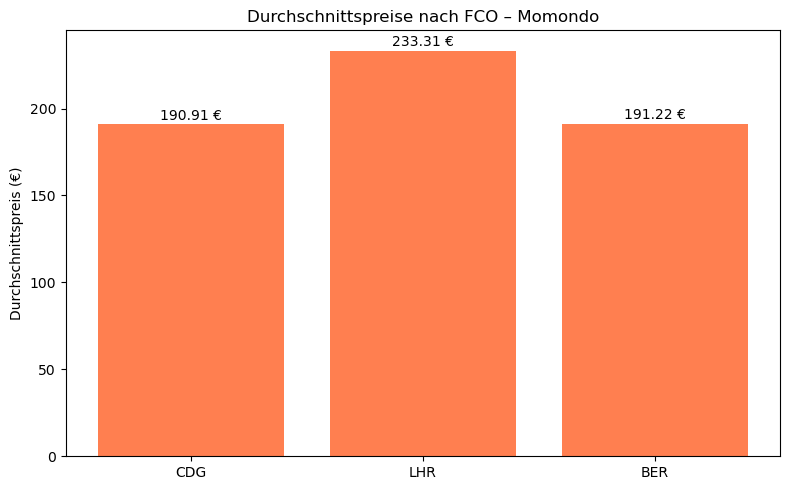

In [7]:
df_avg_pd = df_avg.toPandas()

# Plot erstellen
plt.figure(figsize=(8, 5))
bars = plt.bar(df_avg_pd['Abflug_Flughafen'], df_avg_pd['Durchschnittspreis'], color='coral')
plt.ylabel("Durchschnittspreis (€)")
plt.title("Durchschnittspreise nach FCO – Momondo")

for bar, preis in zip(bars, df_avg_pd['Durchschnittspreis']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{preis:.2f} €",
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()